# CarValue AI — Research-Grade Data Audit, Economic EDA & Modeling Preparation

## Research question
**How accurately can observable vehicle and market-listing characteristics explain and predict used-car asking prices in Vietnam, and what economic patterns can be observed in depreciation, usage, market segmentation, origin, and geographic price dispersion?**

This notebook intentionally separates:

1. **Data evidence** — what the Bonbanh sample directly shows.
2. **Economic interpretation** — hypotheses consistent with economic theory/literature.
3. **Causal claims** — *not made* unless the data design supports them.

> Important: `price_vnd` is an **asking/listing price**, not a verified transaction price. The project predicts market asking prices, not necessarily final negotiated sale prices.


## 0. Related work and research framing

This project is informed by both **machine-learning** and **economic/hedonic-pricing** literature.

### Core related work

1. **Pudaruth (2014), _Predicting the Price of Used Cars using Machine Learning Techniques_**  
   Uses historical used-car data and compares multiple supervised-learning approaches. It illustrates that used-car pricing is not a trivial regression problem and motivates systematic feature/model comparison.

2. **Amik et al. (2021), _Application of Machine Learning Techniques to Predict the Price of Pre-Owned Cars in Bangladesh_, Information 12(12):514. DOI: 10.3390/info12120514**  
   Particularly relevant to this project: the authors collect real marketplace data, perform EDA, compare Linear Regression/LASSO/Decision Tree/Random Forest/XGBoost, and deploy the selected model as a web application. Their XGBoost model reports an R² around 91% in their setting.

3. **Arora, Gupta & Singh (2022), _Forecasting resale value of the car: Evaluating the proficiency under the impact of machine learning model_, Materials Today: Proceedings. DOI: 10.1016/j.matpr.2022.09.074**  
   Finds year of manufacture, distance driven, fuel type and transmission among important contributors and compares XGBoost with several baselines.

4. **Engers, Hartmann & Stern (2009), _Annual miles drive used car prices_, Journal of Applied Econometrics. DOI: 10.1002/jae.1034**  
   Provides an economic interpretation of vehicle depreciation: age, mileage/usage and the stream of vehicle services are connected to resale values.

5. **Lacetera, Pope & Sydnor (2012/2017 online-market literature on salience; related Management Science evidence)**  
   Online used-car markets can exhibit nonlinear price discontinuities around salient age/mileage thresholds (e.g., round odometer levels). This motivates testing nonlinear mileage and age effects rather than assuming a purely linear relationship.

### How our project differs

- Data are collected from **Bonbanh.com**, a Vietnamese used-car marketplace.
- We explicitly audit scraping/preprocessing inconsistencies before modeling.
- We retain provenance flags for recovered target values and missing location.
- We examine both predictive performance and economic patterns such as depreciation, mileage intensity, origin premium, brand concentration and market segmentation.
- We avoid treating macroeconomic factors as model features when the data do not contain reliable listing dates.

### External Vietnamese market context

Vietnamese vehicle ownership has policy-related transaction costs. Government regulations specify registration / registration-tax rules, and the rules can change over time. These can influence buyer total acquisition cost, but they are **not the same as the seller's asking price** and cannot be causally estimated from this cross-sectional snapshot. They belong in the discussion/context section, not blindly in the ML feature matrix.


In [1]:
import pandas as pd
import numpy as np
import re
import hashlib
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

RAW_PATH = "bonbanh_usedcar_dataset (3).csv"
df = pd.read_csv(RAW_PATH)

print("Raw shape:", df.shape)
display(df.head())


Raw shape: (23187, 14)


,brand,model,year,price_vnd,mileage_km,condition,origin,body_type,transmission,engine,exterior_color,seats,drivetrain,location
0,Audi,A5 Sportback 2.0,"2,017.00","799,000,000.00",0 Km,Xe đã dùng,Nhập khẩu,Sedan,Số tự động,Xăng 2.0 L,Trắng,5 chỗ,AWD - 4 bánh toàn thời gian,Bà Rịa Vũng Tàu
1,BMW,3 Series 318i AT,"2,004.00","80,000,000.00","160,000 Km",Xe đã dùng,Lắp ráp trong nước,Sedan,Số tự động,Xăng 2.0 L,Đen,5 chỗ,RFD - Dẫn động cầu sau,Bà Rịa Vũng Tàu
2,BMW,X1 sDrive20i,"2,016.00","568,000,000.00","70,000 Km",Xe đã dùng,Nhập khẩu,SUV,Số tự động,Xăng 2.0 L,Đen,5 chỗ,RFD - Dẫn động cầu sau,Bà Rịa Vũng Tàu
3,BYD,Atto 3 Premium,"2,024.00","610,000,000.00","47,000 Km",Xe đã dùng,Nhập khẩu,Crossover,Số tự động,Điện,Bạc,5 chỗ,FWD - Dẫn động cầu trước,Bà Rịa Vũng Tàu
4,Chevrolet,Cruze LTZ 1.8 AT,"2,013.00","185,000,000.00",0 Km,Xe đã dùng,Lắp ráp trong nước,Sedan,Số tự động,Xăng 1.8 L,Bạc,5 chỗ,FWD - Dẫn động cầu trước,Bà Rịa Vũng Tàu


## 1. Data provenance and raw-data audit

In [2]:
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_n": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "unique_n": df.nunique(dropna=True)
}).sort_values("missing_pct", ascending=False)

display(audit)
print("Exact equal rows in exported feature table:", df.duplicated().sum())
print("\nCondition values:")
display(df["condition"].value_counts(dropna=False))


,dtype,missing_n,missing_pct,unique_n
location,object,9444,40.73,62
price_vnd,float64,3911,16.87,1611
model,object,0,0.00,5117
year,float64,0,0.00,38
mileage_km,object,0,0.00,1771
brand,object,0,0.00,80
condition,object,0,0.00,1
origin,object,0,0.00,2
transmission,object,0,0.00,3
body_type,object,0,0.00,10


Exact equal rows in exported feature table: 1551

Condition values:


condition
Xe đã dùng    23187
Name: count, dtype: int64

### Audit interpretation

The exported CSV has already lost the original listing URL / listing ID. Therefore, **exactly equal feature rows are not automatically proven duplicate listings**. Two different cars can share the same visible specifications and asking price.

Accordingly, this notebook **does not blindly drop all duplicate-looking rows**. Instead, it constructs a `vehicle_signature` and recommends **group-aware train/test splitting** so near-identical records cannot leak across evaluation sets.


## 2. Repair inconsistent target preprocessing

In [3]:
def extract_price_from_text(text):
    if pd.isna(text):
        return np.nan
    t = str(text).lower().strip().replace(",", ".")
    m = re.search(r'(\d+(?:\.\d+)?)\s*(?:tỷ|tỉ)(?:\s*(\d+(?:\.\d+)?)\s*(?:triệu|tr))?', t)
    if m:
        ty = float(m.group(1))
        tr = float(m.group(2)) if m.group(2) else 0.0
        return int(round(ty * 1_000_000_000 + tr * 1_000_000))
    m = re.search(r'(\d+(?:\.\d+)?)\s*(?:triệu|tr)\b', t)
    if m:
        return int(round(float(m.group(1)) * 1_000_000))
    return np.nan

recovered = df["model"].apply(extract_price_from_text)
missing_price = df["price_vnd"].isna()

print("Missing price_vnd before repair:", missing_price.sum())
print("Recoverable from model text:", recovered[missing_price].notna().sum())

examples = df.loc[missing_price, ["brand","model","year","price_vnd"]].copy()
examples["recovered_price"] = recovered[missing_price]
display(examples.head(12))


Missing price_vnd before repair: 3911
Recoverable from model text: 3911


,brand,model,year,price_vnd,recovered_price
422,Acura,MDX 3.7L 2008 - 260 Triệu,"2,008.00",NaN,"260,000,000.00"
423,Acura,MDX SH-AWD 2007 - 255 Triệu,"2,007.00",NaN,"255,000,000.00"
424,Aston,Martin DB11 4.0 V8 2021 - 9 Tỷ 999 Triệu,"2,021.00",NaN,"9,999,000,000.00"
425,Audi,A1 1.4 TFSI 2010 - 339 Triệu,"2,010.00",NaN,"339,000,000.00"
426,Audi,A1 1.4 TFSI 2010 - 290 Triệu,"2,010.00",NaN,"290,000,000.00"
427,Audi,A1 1.4 TFSI 2010 - 219 Triệu,"2,010.00",NaN,"219,000,000.00"
428,Audi,A1 2.0T S-line 2012 - 385 Triệu,"2,012.00",NaN,"385,000,000.00"
429,Audi,A1 2.0T S-line 2012 - 399 Triệu,"2,012.00",NaN,"399,000,000.00"
430,Audi,A3 1.8 AT 2013 - 450 Triệu,"2,013.00",NaN,"450,000,000.00"
431,Audi,A4 1.8 TFSI 2013 - 370 Triệu,"2,013.00",NaN,"370,000,000.00"


**Decision:** recover `price_vnd` only when the original target is missing and a price expression is explicitly present in the malformed model string. We also keep `price_recovered_flag` so downstream analysis can test whether repaired rows behave differently.


## 3. Rebuild model names and normalize known brand parsing errors

In [4]:
def strip_price_suffix(text):
    if pd.isna(text):
        return text
    s = str(text).strip()
    s = re.sub(
        r'\s*[-–—]\s*\d+(?:[.,]\d+)?\s*(?:tỷ|tỉ)(?:\s*\d+(?:[.,]\d+)?\s*(?:triệu|tr))?\s*$',
        '', s, flags=re.I
    )
    s = re.sub(r'\s*[-–—]\s*\d+(?:[.,]\d+)?\s*(?:triệu|tr)\s*$', '', s, flags=re.I)
    return re.sub(r'\s+', ' ', s).strip()

def strip_trailing_year(model, year):
    if pd.isna(model):
        return model
    s = str(model).strip()
    if pd.notna(year):
        y = str(int(float(year)))
        s = re.sub(rf'\s+{re.escape(y)}\s*$', '', s).strip()
    return s

def normalize_brand_model(brand, model):
    b = "" if pd.isna(brand) else str(brand).strip()
    m = "" if pd.isna(model) else str(model).strip()

    rules = [
        ("Mercedes", r"^Benz\s+", "Mercedes-Benz"),
        ("Rolls", r"^Royce\s+", "Rolls-Royce"),
        ("Aston", r"^Martin\s+", "Aston Martin"),
        ("Lynk", r"^&\s*Co\s+", "Lynk & Co"),
    ]

    for base_brand, prefix_re, normalized_brand in rules:
        if b.lower() == base_brand.lower():
            b = normalized_brand
            m = re.sub(prefix_re, "", m, flags=re.I).strip()
            break

    if b == "LandRover":
        b = "Land Rover"

    return b, m

clean = df.copy()
clean["model_raw"] = clean["model"]
clean["price_original"] = clean["price_vnd"]

recovered = clean["model_raw"].apply(extract_price_from_text)
mask = clean["price_vnd"].isna() & recovered.notna()
clean.loc[mask, "price_vnd"] = recovered[mask]
clean["price_recovered_flag"] = mask.astype(int)

clean["model"] = clean.apply(
    lambda r: strip_trailing_year(strip_price_suffix(r["model_raw"]), r["year"]),
    axis=1
)

normalized = clean.apply(
    lambda r: normalize_brand_model(r["brand"], r["model"]),
    axis=1
)
clean["brand"] = [x[0] for x in normalized]
clean["model"] = [x[1] for x in normalized]

display(clean.loc[clean["price_recovered_flag"].eq(1),
                  ["brand","model_raw","model","price_vnd"]].head(15))


,brand,model_raw,model,price_vnd
422,Acura,MDX 3.7L 2008 - 260 Triệu,MDX 3.7L,"260,000,000.00"
423,Acura,MDX SH-AWD 2007 - 255 Triệu,MDX SH-AWD,"255,000,000.00"
424,Aston Martin,Martin DB11 4.0 V8 2021 - 9 Tỷ 999 Triệu,DB11 4.0 V8,"9,999,000,000.00"
425,Audi,A1 1.4 TFSI 2010 - 339 Triệu,A1 1.4 TFSI,"339,000,000.00"
426,Audi,A1 1.4 TFSI 2010 - 290 Triệu,A1 1.4 TFSI,"290,000,000.00"
427,Audi,A1 1.4 TFSI 2010 - 219 Triệu,A1 1.4 TFSI,"219,000,000.00"
428,Audi,A1 2.0T S-line 2012 - 385 Triệu,A1 2.0T S-line,"385,000,000.00"
429,Audi,A1 2.0T S-line 2012 - 399 Triệu,A1 2.0T S-line,"399,000,000.00"
430,Audi,A3 1.8 AT 2013 - 450 Triệu,A3 1.8 AT,"450,000,000.00"
431,Audi,A4 1.8 TFSI 2013 - 370 Triệu,A4 1.8 TFSI,"370,000,000.00"


## 4. Parse mileage, engine and seats — without hiding uncertainty

In [5]:
def parse_mileage(x):
    if pd.isna(x):
        return np.nan
    nums = re.sub(r"[^\d]", "", str(x))
    return float(nums) if nums else np.nan

def parse_seats(x):
    if pd.isna(x):
        return np.nan
    m = re.search(r"(\d+)", str(x))
    return float(m.group(1)) if m else np.nan

def parse_engine(x):
    if pd.isna(x):
        return (np.nan, np.nan)
    s = re.sub(r"\s+", " ", str(x).strip())
    m = re.search(r"(\d+(?:[.,]\d+)?)\s*L", s, flags=re.I)
    engine_size = float(m.group(1).replace(",", ".")) if m else np.nan
    fuel = re.sub(r"\s*\d+(?:[.,]\d+)?\s*L.*$", "", s, flags=re.I).strip()
    return (fuel if fuel else np.nan, engine_size)

clean["mileage_km_raw"] = clean["mileage_km"]
clean["mileage_km"] = clean["mileage_km"].apply(parse_mileage)
clean["mileage_zero_flag"] = (clean["mileage_km"] == 0).astype(int)

# A zero reading in an all-used-car marketplace may mean "not provided".
# Baseline treatment: missing + explicit indicator, rather than assuming true zero.
clean.loc[clean["mileage_km"] == 0, "mileage_km"] = np.nan

clean["seats_raw"] = clean["seats"]
clean["seats"] = clean["seats"].apply(parse_seats)

engine_info = clean["engine"].apply(parse_engine)
clean["fuel_type"] = engine_info.apply(lambda x: x[0])
clean["engine_size_l"] = engine_info.apply(lambda x: x[1])

for c in ["transmission", "drivetrain"]:
    clean[c] = clean[c].replace("-", np.nan)

clean["year"] = pd.to_numeric(clean["year"], errors="coerce")
clean["price_vnd"] = pd.to_numeric(clean["price_vnd"], errors="coerce")

reference_year = int(clean["year"].max())
clean["car_age"] = reference_year - clean["year"]
clean["annual_km"] = clean["mileage_km"] / clean["car_age"].replace(0, 1)
clean["location_missing_flag"] = clean["location"].isna().astype(int)

print("Reference year:", reference_year)
print("0-km values flagged:", clean["mileage_zero_flag"].sum())
display(clean[["mileage_km_raw","mileage_km","engine","fuel_type","engine_size_l","seats"]].head(10))


Reference year: 2026
0-km values flagged: 3249


,mileage_km_raw,mileage_km,engine,fuel_type,engine_size_l,seats
0,0 Km,NaN,Xăng 2.0 L,Xăng,2.00,5.00
1,"160,000 Km","160,000.00",Xăng 2.0 L,Xăng,2.00,5.00
2,"70,000 Km","70,000.00",Xăng 2.0 L,Xăng,2.00,5.00
3,"47,000 Km","47,000.00",Điện,Điện,NaN,5.00
4,0 Km,NaN,Xăng 1.8 L,Xăng,1.80,5.00
5,0 Km,NaN,Xăng 0.8 L,Xăng,0.80,5.00
6,"80,000 Km","80,000.00",Xăng 1.0 L,Xăng,1.00,5.00
7,0 Km,NaN,Xăng 0.8 L,Xăng,0.80,5.00
8,"68,000 Km","68,000.00",Xăng 1.0 L,Xăng,1.00,5.00
9,"90,000 Km","90,000.00",Xăng 1.5 L,Xăng,1.50,5.00


## 5. Data-quality diagnostics before economic EDA

In [6]:
post_audit = pd.DataFrame({
    "missing_n": clean.isna().sum(),
    "missing_pct": (clean.isna().mean() * 100).round(2),
    "unique_n": clean.nunique(dropna=True)
}).sort_values("missing_pct", ascending=False)

display(post_audit.head(20))

print("Recovered price rows:", clean["price_recovered_flag"].sum())
print("Remaining missing prices:", clean["price_vnd"].isna().sum())
print("Missing locations:", clean["location"].isna().sum())
print("Condition unique values:", clean["condition"].nunique(dropna=False))


,missing_n,missing_pct,unique_n
location,9444,40.73,62
price_original,3911,16.87,1611
annual_km,3249,14.01,2925
mileage_km,3249,14.01,1770
engine_size_l,1188,5.12,55
transmission,2,0.01,2
drivetrain,2,0.01,4
year,0,0.00,38
brand,0,0.00,80
body_type,0,0.00,10


Recovered price rows: 3911
Remaining missing prices: 0
Missing locations: 9444
Condition unique values: 1


,count,median,mean,min,max
price_recovered_flag,,,,,
0,19276,"545,000,000.00","951,892,353.19","16,000,000.00","66,000,000,000.00"
1,3911,"655,000,000.00","1,197,477,371.52","29,000,000.00","15,868,000,000.00"


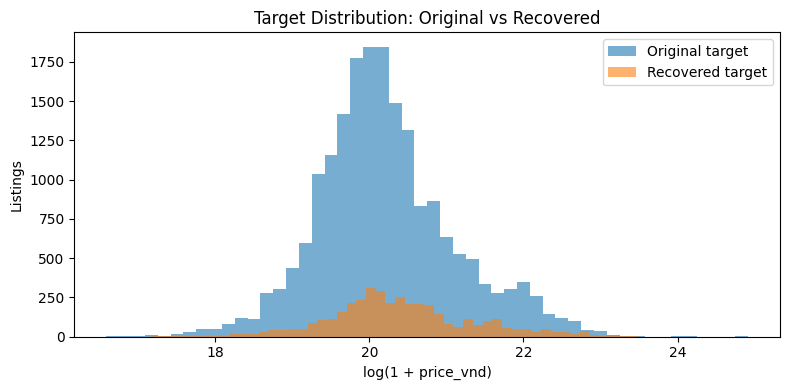

In [7]:
# Compare original vs recovered target distributions as a data-quality check
tmp = clean.dropna(subset=["price_vnd"]).copy()
tmp["price_bn"] = tmp["price_vnd"] / 1e9

display(
    tmp.groupby("price_recovered_flag")["price_vnd"]
       .agg(["count","median","mean","min","max"])
)

plt.figure(figsize=(8,4))
plt.hist(np.log1p(tmp.loc[tmp["price_recovered_flag"].eq(0), "price_vnd"]), bins=50, alpha=0.6, label="Original target")
plt.hist(np.log1p(tmp.loc[tmp["price_recovered_flag"].eq(1), "price_vnd"]), bins=50, alpha=0.6, label="Recovered target")
plt.xlabel("log(1 + price_vnd)")
plt.ylabel("Listings")
plt.title("Target Distribution: Original vs Recovered")
plt.legend()
plt.tight_layout()
plt.show()


If recovered rows have a very different distribution, that does **not automatically mean the repair is wrong**: the malformed rows may originate from a different crawl chunk. It does mean `price_recovered_flag` should be used for sensitivity checks and not as a predictive feature.


## 6. Economic EDA I — Market composition and concentration

Brand-listing HHI: 0.0845
Top-5 brand listing share: 57.15%


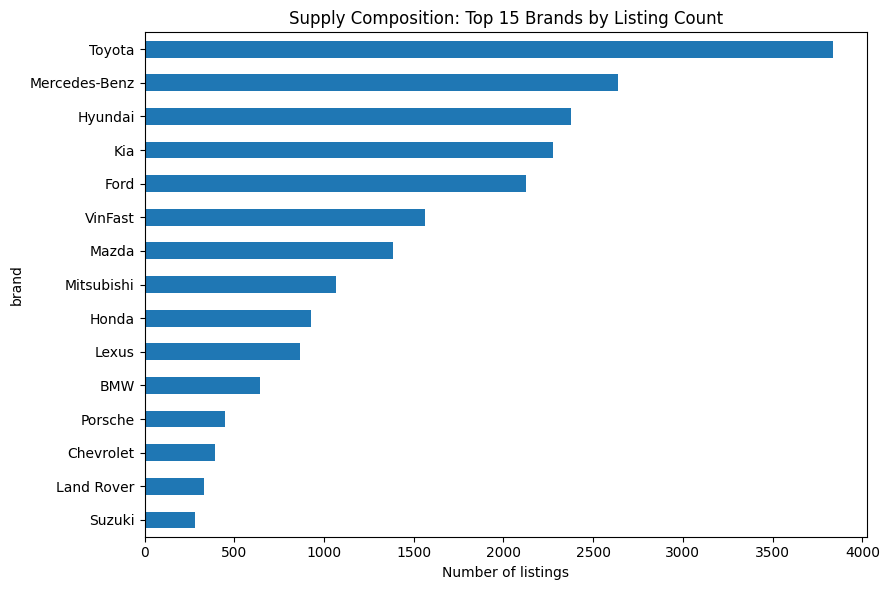

In [8]:
valid = clean[(clean["price_vnd"].notna()) & (clean["price_vnd"] > 0)].copy()

brand_counts = valid["brand"].value_counts()
brand_share = brand_counts / brand_counts.sum()
hhi = float((brand_share ** 2).sum())

print(f"Brand-listing HHI: {hhi:.4f}")
print("Top-5 brand listing share:", f"{brand_share.head(5).sum():.2%}")

plt.figure(figsize=(9,6))
brand_counts.head(15).sort_values().plot(kind="barh")
plt.xlabel("Number of listings")
plt.title("Supply Composition: Top 15 Brands by Listing Count")
plt.tight_layout()
plt.show()


### Economic interpretation
Listing concentration is a proxy for **observed supply composition on the platform**, not national market share. A few highly represented brands can dominate model training, so evaluation should also be segmented by brand/price tier rather than relying only on one aggregate RMSE.


## 7. Economic EDA II — Depreciation by vehicle age

,car_age,count,median,mean
0,0.00,277,"776,000,000.00","1,016,844,765.34"
1,1.00,1670,"755,000,000.00","1,226,902,395.21"
2,2.00,2143,"730,000,000.00","1,101,353,243.12"
3,3.00,2087,"739,000,000.00","1,351,091,039.77"
4,4.00,2886,"697,000,000.00","1,276,548,163.55"
5,5.00,2255,"689,000,000.00","1,363,338,359.20"
6,6.00,1665,"599,000,000.00","1,057,162,162.16"
7,7.00,1874,"550,000,000.00","955,533,084.31"
8,8.00,1539,"485,000,000.00","789,212,475.63"
9,9.00,1064,"485,000,000.00","704,732,142.86"


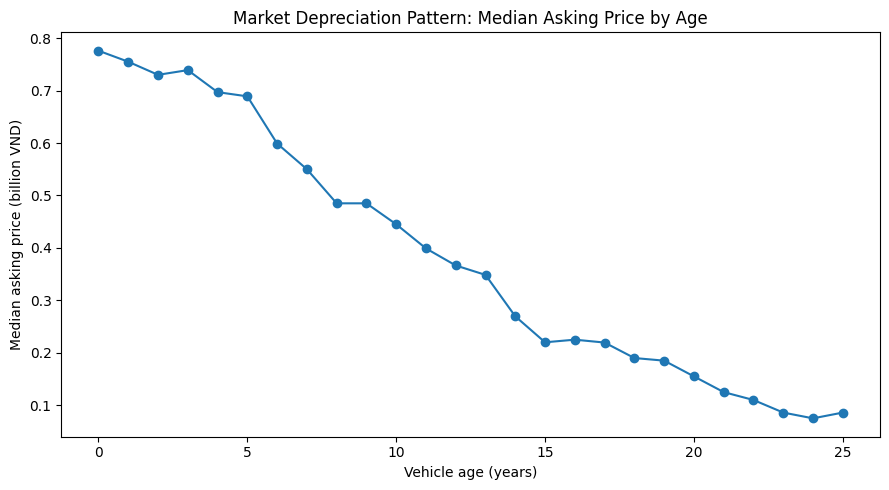

In [9]:
age_stats = (
    valid[(valid["car_age"] >= 0) & (valid["car_age"] <= 25)]
    .groupby("car_age")["price_vnd"]
    .agg(["count","median","mean"])
    .reset_index()
)

display(age_stats.head(15))

plt.figure(figsize=(9,5))
plt.plot(age_stats["car_age"], age_stats["median"] / 1e9, marker="o")
plt.xlabel("Vehicle age (years)")
plt.ylabel("Median asking price (billion VND)")
plt.title("Market Depreciation Pattern: Median Asking Price by Age")
plt.tight_layout()
plt.show()


**Caution:** the raw age-price curve mixes brands, models and segments. It is descriptive, not a pure depreciation rate. A luxury 10-year-old car may still cost more than a new economy car. The next plot conditions on major brands to reduce this composition problem.


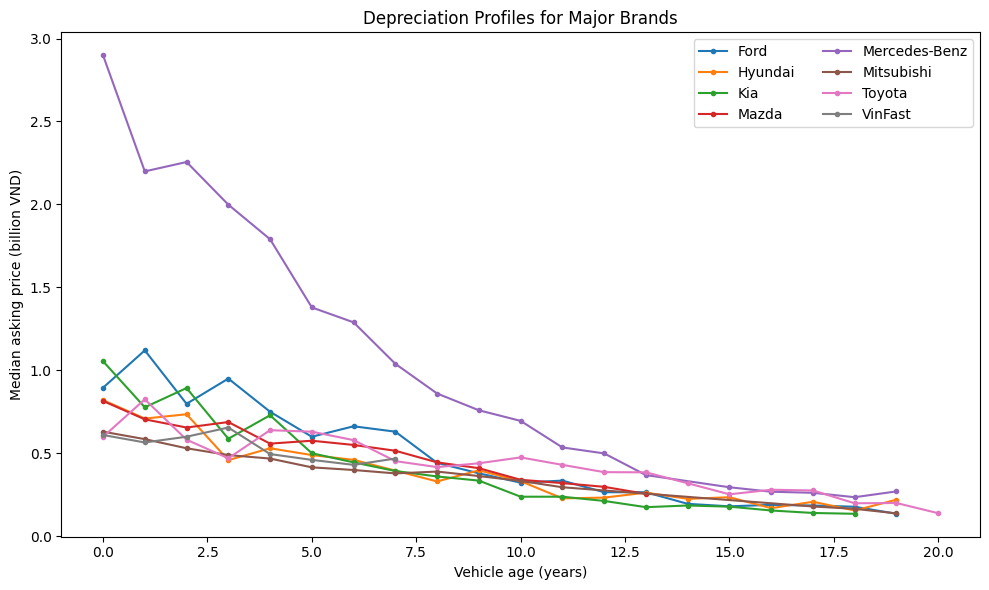

In [10]:
top_brands = valid["brand"].value_counts().head(8).index
brand_age = (
    valid[valid["brand"].isin(top_brands) & valid["car_age"].between(0,20)]
    .groupby(["brand","car_age"])["price_vnd"]
    .agg(["median","count"])
    .reset_index()
)
brand_age = brand_age[brand_age["count"] >= 10]

plt.figure(figsize=(10,6))
for brand, g in brand_age.groupby("brand"):
    plt.plot(g["car_age"], g["median"]/1e9, marker=".", label=brand)
plt.xlabel("Vehicle age (years)")
plt.ylabel("Median asking price (billion VND)")
plt.title("Depreciation Profiles for Major Brands")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


## 8. Economic EDA III — Mileage, usage intensity and salient thresholds

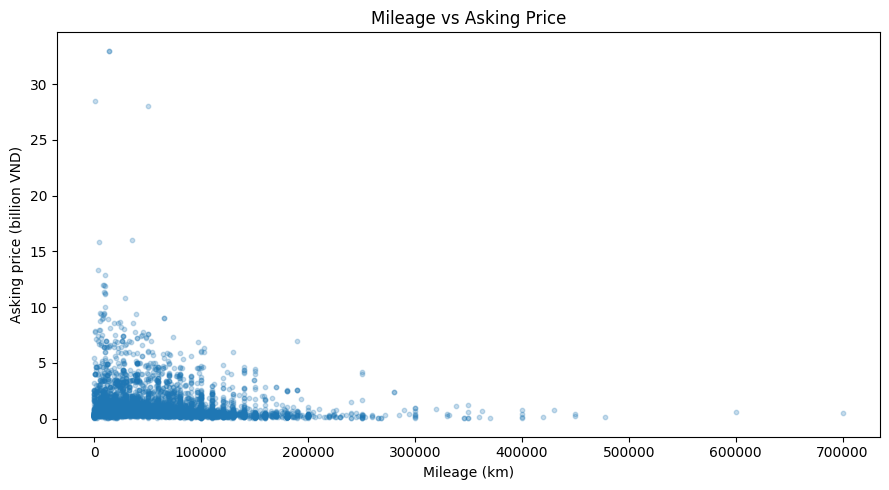

count    19,839.00
mean     12,099.29
std       9,866.77
min           0.10
5%        1,856.60
25%       7,222.22
50%      10,500.00
75%      15,000.00
95%      25,000.00
max     320,000.00
Name: annual_km, dtype: float64

In [11]:
m = valid.dropna(subset=["mileage_km"]).copy()
m = m[(m["mileage_km"] >= 0) & (m["mileage_km"] <= m["mileage_km"].quantile(0.995))]

sample = m.sample(min(6000, len(m)), random_state=42)

plt.figure(figsize=(9,5))
plt.scatter(sample["mileage_km"], sample["price_vnd"]/1e9, alpha=0.25, s=10)
plt.xlabel("Mileage (km)")
plt.ylabel("Asking price (billion VND)")
plt.title("Mileage vs Asking Price")
plt.tight_layout()
plt.show()

display(m["annual_km"].describe(percentiles=[.05,.25,.5,.75,.95]))


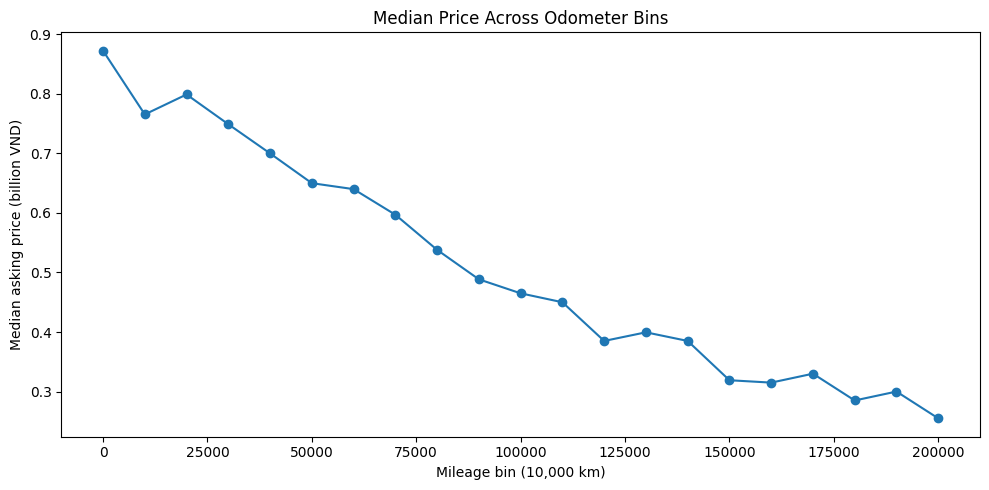

In [12]:
# 10,000-km bins test whether price patterns are visibly nonlinear around odometer ranges
m["mileage_10k_bin"] = (m["mileage_km"] // 10000 * 10000).astype(int)

mileage_bins = (
    m[m["mileage_10k_bin"] <= 200000]
    .groupby("mileage_10k_bin")["price_vnd"]
    .agg(["count","median"])
    .reset_index()
)
mileage_bins = mileage_bins[mileage_bins["count"] >= 30]

plt.figure(figsize=(10,5))
plt.plot(mileage_bins["mileage_10k_bin"], mileage_bins["median"]/1e9, marker="o")
plt.xlabel("Mileage bin (10,000 km)")
plt.ylabel("Median asking price (billion VND)")
plt.title("Median Price Across Odometer Bins")
plt.tight_layout()
plt.show()


The economics literature suggests mileage is more than a mechanical wear variable: it proxies cumulative vehicle use and remaining service flow. Online markets can also display nonlinear responses at salient odometer thresholds, supporting tree/boosting models and spline/nonlinear baselines rather than assuming one constant linear mileage coefficient.


## 9. Economic EDA IV — Imported vs domestically assembled vehicles

,count,median,mean
origin,,,
Lắp ráp trong nước,13142,"500,000,000.00","616,714,655.30"
Nhập khẩu,10045,"680,000,000.00","1,486,027,575.91"


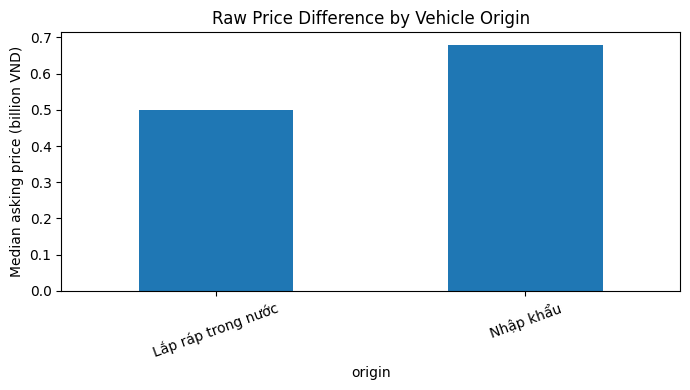

In [13]:
origin_stats = valid.groupby("origin")["price_vnd"].agg(["count","median","mean"])
display(origin_stats)

plt.figure(figsize=(7,4))
origin_stats["median"].sort_values().div(1e9).plot(kind="bar")
plt.ylabel("Median asking price (billion VND)")
plt.title("Raw Price Difference by Vehicle Origin")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


The raw difference is **not a causal import premium**. Imported vehicles may be disproportionately luxury brands, larger engines or premium body types. A better descriptive check compares origin within narrower brand-age-body-type cells.


In [14]:
matched = valid.dropna(subset=["origin","brand","year","body_type"]).copy()

cell = (
    matched.groupby(["brand","year","body_type","origin"])["price_vnd"]
           .agg(["median","count"])
           .reset_index()
)
cell = cell[cell["count"] >= 3]

pivot = cell.pivot_table(
    index=["brand","year","body_type"],
    columns="origin",
    values="median"
)

if {"Nhập khẩu","Lắp ráp trong nước"}.issubset(pivot.columns):
    paired = pivot.dropna(subset=["Nhập khẩu","Lắp ráp trong nước"]).copy()
    paired["import_minus_domestic_pct"] = (
        paired["Nhập khẩu"] / paired["Lắp ráp trong nước"] - 1
    ) * 100
    print("Comparable brand-year-body cells:", len(paired))
    display(paired["import_minus_domestic_pct"].describe())
else:
    print("Not enough matched origin cells for paired comparison.")


Comparable brand-year-body cells: 147


count   147.00
mean     60.89
std      97.64
min     -65.62
25%      -3.84
50%      40.71
75%      98.45
max     496.44
Name: import_minus_domestic_pct, dtype: float64

## 10. Economic EDA V — Price tiers and segmentation

In [15]:
q = valid["price_vnd"].quantile([0,.25,.5,.75,.9,.95,.99,1])
display(q.to_frame("price_vnd"))

valid["price_tier"] = pd.qcut(
    valid["price_vnd"],
    q=[0,.25,.5,.75,.9,1],
    labels=["Entry","Lower-mid","Mid","Upper","Premium"],
    duplicates="drop"
)

tier_mix = pd.crosstab(valid["price_tier"], valid["body_type"], normalize="index")
display((tier_mix * 100).round(1))


,price_vnd
0.00,"16,000,000.00"
0.25,"355,000,000.00"
0.50,"560,000,000.00"
0.75,"999,000,000.00"
0.90,"2,243,600,000.00"
0.95,"3,500,000,000.00"
0.99,"6,950,000,000.00"
1.00,"66,000,000,000.00"


body_type,Bán tải / Pickup,Convertible/Cabriolet,Coupe,Crossover,Hatchback,SUV,Sedan,Truck,Van/Minivan,Wagon
price_tier,,,,,,,,,,
Entry,4.20,0.00,0.30,8.00,27.60,15.10,38.40,1.50,4.90,0.00
Lower-mid,8.50,0.10,0.10,13.80,3.80,37.10,32.90,0.40,3.30,0.00
Mid,6.90,0.20,0.40,11.10,0.50,58.10,15.10,0.20,7.50,0.00
Upper,2.40,1.00,1.90,0.30,1.80,54.90,27.90,0.00,9.70,0.00
Premium,0.30,2.50,3.10,0.20,0.00,68.30,21.80,0.00,3.80,0.00


Segmented error reporting is important because one overall MAE can hide poor performance on premium/luxury vehicles. Later modeling should report **MAE by price tier** in addition to aggregate MAE/RMSE/R².


## 11. Economic EDA VI — Geography, with missingness treated as a sampling issue

Location missing rate: 40.73%


,count,median
location,,
Hà Nội,6958,"720,000,000.00"
Quảng Ninh,184,"570,000,000.00"
Long An,72,"480,000,000.00"
Tây Ninh,102,"468,000,000.00"
Hải Phòng,642,"453,500,000.00"
Vĩnh Phúc,151,"440,000,000.00"
Đà Nẵng,414,"420,000,000.00"
Bắc Ninh,156,"420,000,000.00"
Bà Rịa Vũng Tàu,135,"418,000,000.00"


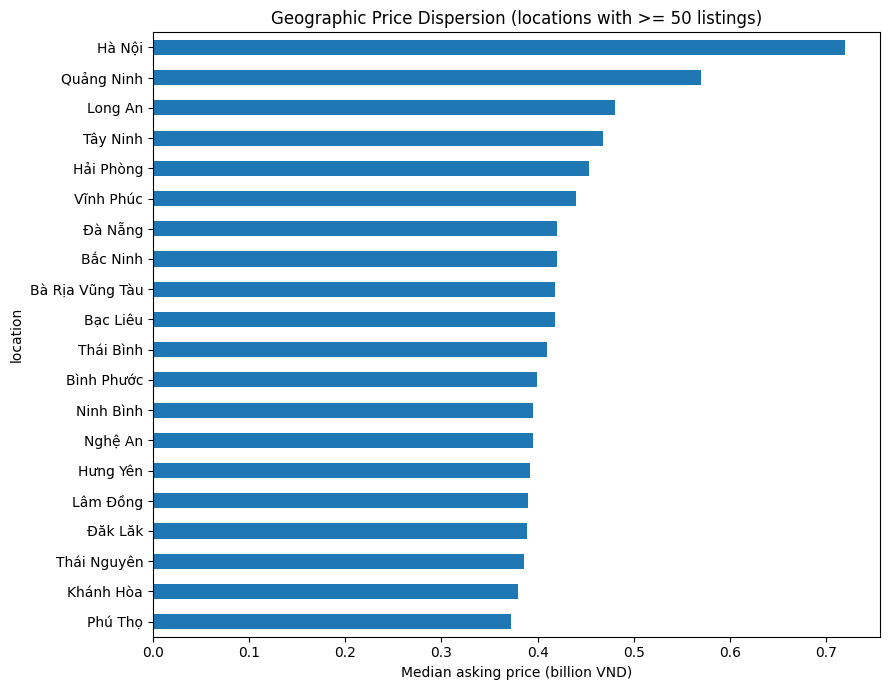

In [16]:
print("Location missing rate:", f"{clean['location'].isna().mean():.2%}")

loc = valid.dropna(subset=["location"]).copy()
loc_stats = (
    loc.groupby("location")["price_vnd"]
       .agg(["count","median"])
       .query("count >= 50")
       .sort_values("median", ascending=False)
)

display(loc_stats.head(20))

plt.figure(figsize=(9,7))
loc_stats.head(20).sort_values("median")["median"].div(1e9).plot(kind="barh")
plt.xlabel("Median asking price (billion VND)")
plt.title("Geographic Price Dispersion (locations with >= 50 listings)")
plt.tight_layout()
plt.show()


Because a large block of `location` is missing due to the crawl/preprocessing pipeline, geography should initially be used for **descriptive analysis only**. The baseline model should exclude location until source-region recovery is reliable. Otherwise, `Unknown` may become a proxy for crawl batch rather than an economic location effect.


## 12. External macro/policy context — what we can and cannot test

Potential macroeconomic drivers of used-car values include:

- inflation and general price levels,
- borrowing costs / auto-loan rates,
- fuel prices,
- new-car supply constraints,
- registration and ownership-transfer costs,
- policies affecting new ICE/EV vehicle acquisition.

However, this dataset lacks a trustworthy **listing date/time series**. Therefore we cannot estimate how inflation, interest rates or policy changes move prices over time from this snapshot.

**Correct research practice:** discuss these as market context and future-data extensions, not as estimated drivers in this version.

A future crawler should store:
`listing_url`, `listing_id`, `crawl_timestamp`, `seller_type`, `location`, and ideally listing-posted date. Then macro series can be joined by month for time-aware modeling.


## 13. Duplicate/leakage-safe modeling preparation

In [17]:
signature_cols = [
    "brand","model","year","mileage_km","origin","body_type",
    "transmission","engine","exterior_color","seats","drivetrain"
]

def stable_signature(row):
    vals = [
        "" if pd.isna(row[c]) else str(row[c]).strip().lower()
        for c in signature_cols
    ]
    return hashlib.sha1("||".join(vals).encode("utf-8")).hexdigest()[:16]

clean["vehicle_signature"] = clean.apply(stable_signature, axis=1)
sig_counts = clean["vehicle_signature"].value_counts()
clean["signature_group_size"] = clean["vehicle_signature"].map(sig_counts)

print("Rows:", len(clean))
print("Unique vehicle signatures:", clean["vehicle_signature"].nunique())
print("Rows in signature groups > 1:", (clean["signature_group_size"] > 1).sum())

display(clean["signature_group_size"].value_counts().sort_index().head(15))


Rows: 23187
Unique vehicle signatures: 18572
Rows in signature groups > 1: 7600


signature_group_size
1     15587
2      4088
3      1782
4       744
5       425
6       192
7       126
8        80
9        54
10       50
11       11
12       48
Name: count, dtype: int64

### Recommended evaluation split

Use `GroupShuffleSplit` (or group-aware cross-validation) with `vehicle_signature` as the grouping key. This keeps identical/near-identical observable vehicles out of both train and test simultaneously, reducing optimistic leakage without claiming every repeated row is a confirmed duplicate.

**Do not use these provenance variables as predictors:**
- `price_recovered_flag`
- `location_missing_flag`
- `vehicle_signature`
- `signature_group_size`
- raw model/title fields


## 14. Candidate feature set and model plan

### Baseline predictors
- brand
- model
- car_age (prefer over using both age and year in the same simple linear model)
- mileage_km
- mileage_zero_flag
- origin
- body_type
- transmission
- fuel_type
- engine_size_l
- exterior_color
- seats
- drivetrain

`condition` is excluded because it is constant in the current data.

`location` is excluded from the **baseline** because missingness is structurally tied to data collection.

### Models
1. **Naive baseline:** median price / brand-model median where available.
2. **Linear / regularized regression:** interpretable benchmark; preferably on `log(price)`.
3. **Random Forest:** nonlinear bagging baseline.
4. **XGBoost:** directly comparable with important related work.
5. **CatBoost:** strong candidate because brand/model and several predictors are high-cardinality categorical variables.

### Evaluation
- MAE (VND and million VND)
- RMSE
- R²
- RMSLE / log-target diagnostics where appropriate
- MAE by price tier
- MAE by major brand
- residual plots
- feature importance + SHAP
- group-aware split to avoid duplicate leakage

The best model must be selected from **unseen grouped test performance**, not training accuracy.


## 15. Export repaired master dataset

In [18]:
clean["target_valid_flag"] = (
    clean["price_vnd"].notna() & (clean["price_vnd"] > 0)
).astype(int)

clean["market_segment"] = np.where(
    clean["body_type"].eq("Truck"),
    "Commercial/Truck",
    "Passenger/Light vehicle"
)

clean.to_csv(
    "CarValue_AI_master_repaired.csv",
    index=False,
    encoding="utf-8-sig"
)

model_candidate = clean[
    clean["price_vnd"].notna() & (clean["price_vnd"] > 0)
].copy()

model_candidate.to_csv(
    "CarValue_AI_model_candidate.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Master:", clean.shape)
print("Model candidate:", model_candidate.shape)
print("Recovered target rows:", clean["price_recovered_flag"].sum())
print("Remaining missing target:", clean["price_vnd"].isna().sum())


Master: (23187, 29)
Model candidate: (23187, 29)
Recovered target rows: 3911
Remaining missing target: 0


## 16. References

- Amik, F. R., Lanard, A., Ismat, A., & Momen, S. (2021). **Application of Machine Learning Techniques to Predict the Price of Pre-Owned Cars in Bangladesh.** *Information*, 12(12), 514. https://doi.org/10.3390/info12120514
- Arora, P., Gupta, H., & Singh, A. (2022). **Forecasting resale value of the car: Evaluating the proficiency under the impact of machine learning model.** *Materials Today: Proceedings*. https://doi.org/10.1016/j.matpr.2022.09.074
- Pudaruth, S. (2014). **Predicting the Price of Used Cars using Machine Learning Techniques.** *International Journal of Information & Computation Technology*, 4(7), 753–764.
- Engers, M., Hartmann, M., & Stern, S. (2009). **Annual miles drive used car prices.** *Journal of Applied Econometrics*. https://doi.org/10.1002/jae.1034
- **Price Discontinuities in an Online Market for Used Cars.** *Management Science*. https://doi.org/10.1287/mnsc.2016.2714
- Government of Vietnam, **Decree 10/2022/NĐ-CP** on registration fees; subsequent amendments should be checked for the exact market period analyzed.

### Research limitation statement
This project estimates **online asking prices** from a single marketplace snapshot. It does not observe negotiated transaction prices, time-on-market, seller identity/type, accidents/service history, ownership count, or a complete temporal macroeconomic panel. These limitations must accompany any business interpretation.
